# QC Benchmark — Hybrid → Paired Transfer

Train QC model on **hybrid recordings** (large, many GT units).  
Evaluate on **paired recordings** (real biology, juxtacellular ground truth, 1 GT unit per recording).

This answers the key scientific question:  
*Does a model trained on synthetic/hybrid data generalize to biologically-confirmed real neurons?*

In [19]:
import importlib, subprocess, sys
for pkg in ["lightgbm", "shap", "seaborn", "pyarrow", "scipy"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

In [20]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from qc_framework.pipeline import QCDatasetReviewPipeline
from qc_framework.data import QCDataLoader, QCDataCleaner
from qc_framework.features import FeatureSetBuilder
from qc_framework.models import QCTrainer
from qc_framework.evaluation import QCEvaluator, JointEvaluator, SHAPAnalyzer

warnings.filterwarnings("ignore", message="X does not have valid feature names")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130

# ═══════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════
PARQUET_PATH   = PROJECT_ROOT / "data" / "raw" / "33000_ROWS.parquet"

TARGETS        = ["accuracy", "fpos", "fmiss_extended"]
RANDOM_STATE   = 42

OUTPUT_DIR     = PROJECT_ROOT / "analysis" / "runs" / (PARQUET_PATH.stem.lower() + "_hybrid_to_paired") / "outputs"
# ═══════════════════════════════════════════════════════

assert PARQUET_PATH.exists(), f"Missing: {PARQUET_PATH}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Parquet:", PARQUET_PATH)
print("Output :", OUTPUT_DIR)

Parquet: /Users/paulruiz/Documents/Predicting_Good_Units/data/raw/33000_ROWS.parquet
Output : /Users/paulruiz/Documents/Predicting_Good_Units/analysis/runs/33000_rows_hybrid_to_paired/outputs


## 1. Load & Split by Dataset Type

In [21]:
loader = QCDataLoader()
cleaner = QCDataCleaner()

full_df = loader.load(PARQUET_PATH)

# ── Training set: hybrid recordings ──────────────────────────────────────────
hybrid_raw = full_df[full_df["dataset_type"] == "hybrid"].copy()
train_df, _ = cleaner.clean(hybrid_raw)

# ── Test set: paired matched units only ──────────────────────────────────────
# Juxtacellular recordings confirm 1 GT neuron per placement.
# We evaluate on sorter units that were matched to that neuron (accuracy > 0
# or matched_gt_unit_id set).  Unmatched sorter units (accuracy=0) are not
# meaningful regression targets and are excluded here.
paired_raw = full_df[full_df["dataset_type"] == "paired"].copy()
paired_clean, _ = cleaner.clean(paired_raw)

matched_mask = (
    pd.to_numeric(paired_clean.get("accuracy", pd.Series(dtype=float)), errors="coerce").fillna(0) > 0
) | (
    paired_clean["matched_gt_unit_id"].notna()
    if "matched_gt_unit_id" in paired_clean.columns
    else pd.Series(False, index=paired_clean.index)
)
test_df = paired_clean[matched_mask].copy()

# Also add fmiss_extended to test set
print(f"Train (hybrid)        : {len(train_df):,} rows | {train_df['recording_key'].nunique()} recordings | {train_df['sorter_name'].nunique()} sorters")
print(f"Test  (paired matched): {len(test_df):,} rows  | {test_df['recording_key'].nunique()} recordings | {test_df['sorter_name'].nunique()} sorters")
print()

review = QCDatasetReviewPipeline(PARQUET_PATH)
available_targets = [t for t in TARGETS if t in test_df.columns]
print("Test target distribution (paired matched units):")
display(review.target_summary(test_df, available_targets))
print()
print("Test rows per study set:")
display(test_df.groupby("study_set").agg(
    rows=("accuracy", "count"),
    recordings=("recording_name", "nunique"),
    acc_mean=("accuracy", "mean"),
    acc_std=("accuracy", "std"),
    acc_min=("accuracy", "min"),
    acc_max=("accuracy", "max"),
).round(3))

Train (hybrid)        : 24,211 rows | 60 recordings | 8 sorters
Test  (paired matched): 207 rows  | 29 recordings | 9 sorters

Test target distribution (paired matched units):


,target,rows,missing_fraction,mean,std,q05,q50,q95
0,accuracy,207,0.0,0.608210,0.300866,0.126933,0.670169,0.974731
1,fpos,207,0.0,0.219017,0.240942,0.005662,0.126797,0.784398
2,fmiss_extended,207,0.0,0.286075,0.287637,0.001284,0.183440,0.831428



Test rows per study set:


,rows,recordings,acc_mean,acc_std,acc_min,acc_max
study_set,,,,,,
PAIRED_BOYDEN,43,4,0.581,0.259,0.119,0.868
PAIRED_CRCNS_HC1,22,4,0.598,0.322,0.111,0.969
PAIRED_ENGLISH,71,13,0.501,0.303,0.101,0.998
PAIRED_KAMPFF,35,4,0.692,0.271,0.168,0.989
PAIRED_MEA64C_YGER,36,4,0.777,0.273,0.115,0.999


## 2. Feature Spaces (built on hybrid train set)

In [23]:
dup_pairs = FeatureSetBuilder.find_exact_duplicate_pairs(train_df)
extra_drop = {b for _, b in dup_pairs}
builder = FeatureSetBuilder()

specs = [
    builder.build(train_df, mode="unit_only",          exclude_soft=False, extra_drop_cols=extra_drop),
    builder.build(train_df, mode="unit_plus_recording", exclude_soft=False, extra_drop_cols=extra_drop),
]

display(pd.DataFrame([
    {"mode": s.mode, "n_numeric": len(s.numeric_cols), "n_categorical": len(s.categorical_cols), "n_total": len(s.all_features)}
    for s in specs
]))

,mode,n_numeric,n_categorical,n_total
0,unit_only,164,0,164
1,unit_plus_recording,169,0,169


## 3. Train on Hybrid → Evaluate on Paired Matched

No grouped split here — the train/test boundary is the dataset type itself.  
This is an out-of-distribution generalization test.

In [24]:
trainer = QCTrainer(
    random_state=RANDOM_STATE,
    min_train_rows=200,
    min_test_rows=5,       # paired matched set is small (207 rows)
)

results = trainer.fit_all(
    train=train_df,
    test=test_df,
    targets=TARGETS,
    specs=specs,
    split_name="hybrid_to_paired",
)

results_df = QCEvaluator.results_table(results)
display(results_df)

,target,split,feature_mode,model,n_train,n_test,mae,rmse,r2,bias
1,accuracy,hybrid_to_paired,unit_only,random_forest,24211,207,0.270634,0.322811,-0.156788,-0.134818
0,accuracy,hybrid_to_paired,unit_only,dummy,24211,207,0.290939,0.326986,-0.186908,-0.129758
2,accuracy,hybrid_to_paired,unit_only,lightgbm,24211,207,0.263250,0.334792,-0.244253,-0.185585
7,fmiss_extended,hybrid_to_paired,unit_only,random_forest,24211,207,0.288530,0.349163,-0.480712,0.190646
8,fmiss_extended,hybrid_to_paired,unit_only,lightgbm,24211,207,0.275101,0.355332,-0.533494,0.183148
6,fmiss_extended,hybrid_to_paired,unit_only,dummy,24211,207,0.323761,0.358849,-0.564003,0.215493
3,fpos,hybrid_to_paired,unit_only,dummy,24211,207,0.212785,0.249449,-0.077065,0.066725
4,fpos,hybrid_to_paired,unit_only,random_forest,24211,207,0.242487,0.275676,-0.315456,0.154496
5,fpos,hybrid_to_paired,unit_only,lightgbm,24211,207,0.256144,0.313022,-0.696007,0.190116
10,accuracy,hybrid_to_paired,unit_plus_recording,random_forest,24211,207,0.270621,0.322988,-0.158061,-0.135256


## 4. Predictions vs Ground Truth (unit_only / LightGBM)

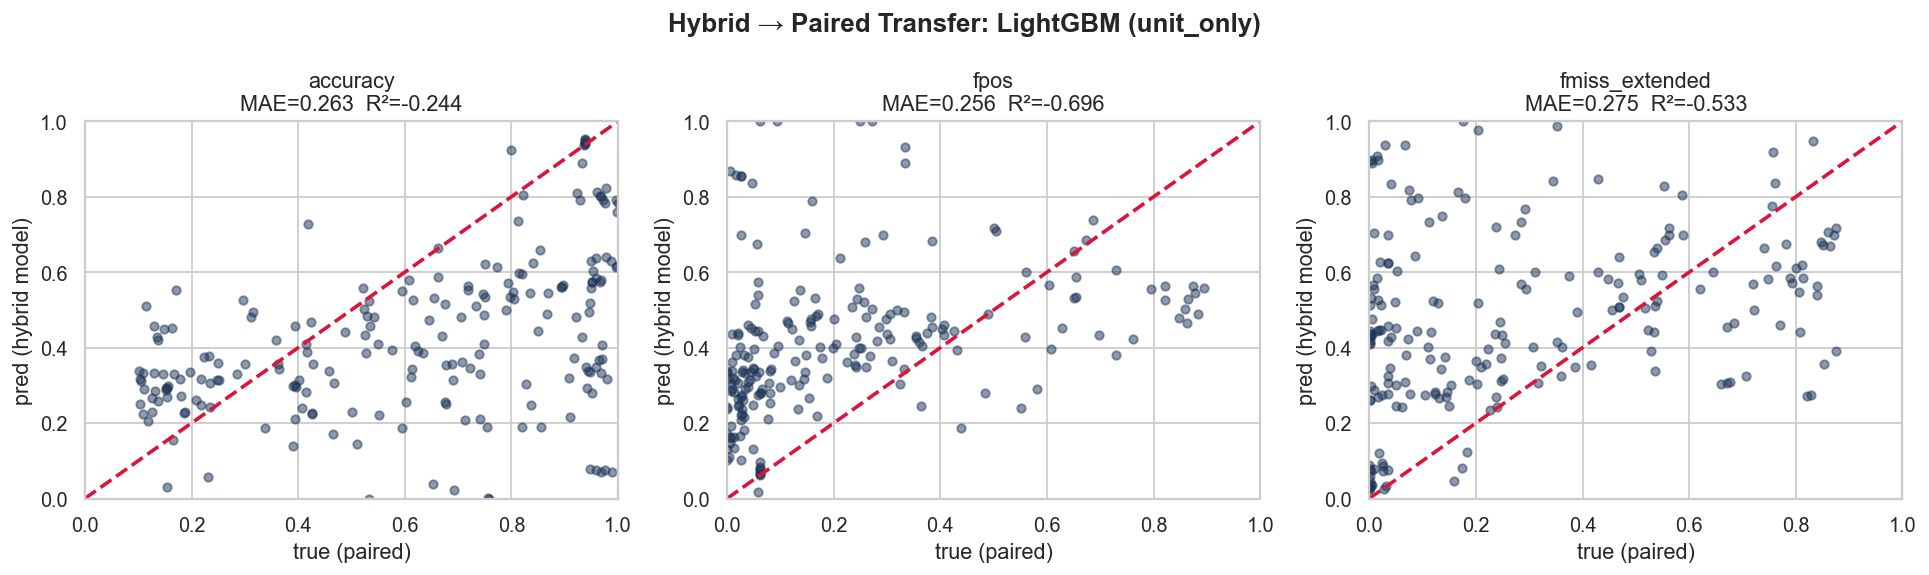

In [25]:
available_targets = [t for t in TARGETS if t in test_df.columns]
fig, axes = plt.subplots(1, len(available_targets), figsize=(5 * len(available_targets), 4.5))
if len(available_targets) == 1:
    axes = [axes]

for ax, target in zip(axes, available_targets):
    result = next((r for r in results
                   if r.target == target
                   and r.feature_mode == "unit_only"
                   and r.model_name == "lightgbm"), None)
    if result is None:
        ax.axis("off"); continue
    p = result.predictions
    ax.scatter(p["true"], p["pred"], s=22, alpha=0.5, color="#1d3557")
    ax.plot([0, 1], [0, 1], color="crimson", lw=2, ls="--")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{target}\nMAE={result.mae:.3f}  R²={result.r2:.3f}")
    ax.set_xlabel("true (paired)"); ax.set_ylabel("pred (hybrid model)")

fig.suptitle("Hybrid → Paired Transfer: LightGBM (unit_only)", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Per Study Set Breakdown

/var/folders/75/5c736b4d4tnfg3yq427dhr6m0000gn/T/ipykernel_52040/2071633029.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  breakdown = p.groupby("study_set").apply(lambda g: pd.Series({


,study_set,n,mae,rmse,mean_true,mean_pred
0,PAIRED_BOYDEN,43.0,0.306,0.364,0.581,0.317
1,PAIRED_CRCNS_HC1,22.0,0.324,0.386,0.598,0.376
2,PAIRED_ENGLISH,71.0,0.257,0.315,0.501,0.341
3,PAIRED_KAMPFF,35.0,0.289,0.406,0.692,0.435
4,PAIRED_MEA64C_YGER,36.0,0.163,0.198,0.777,0.726


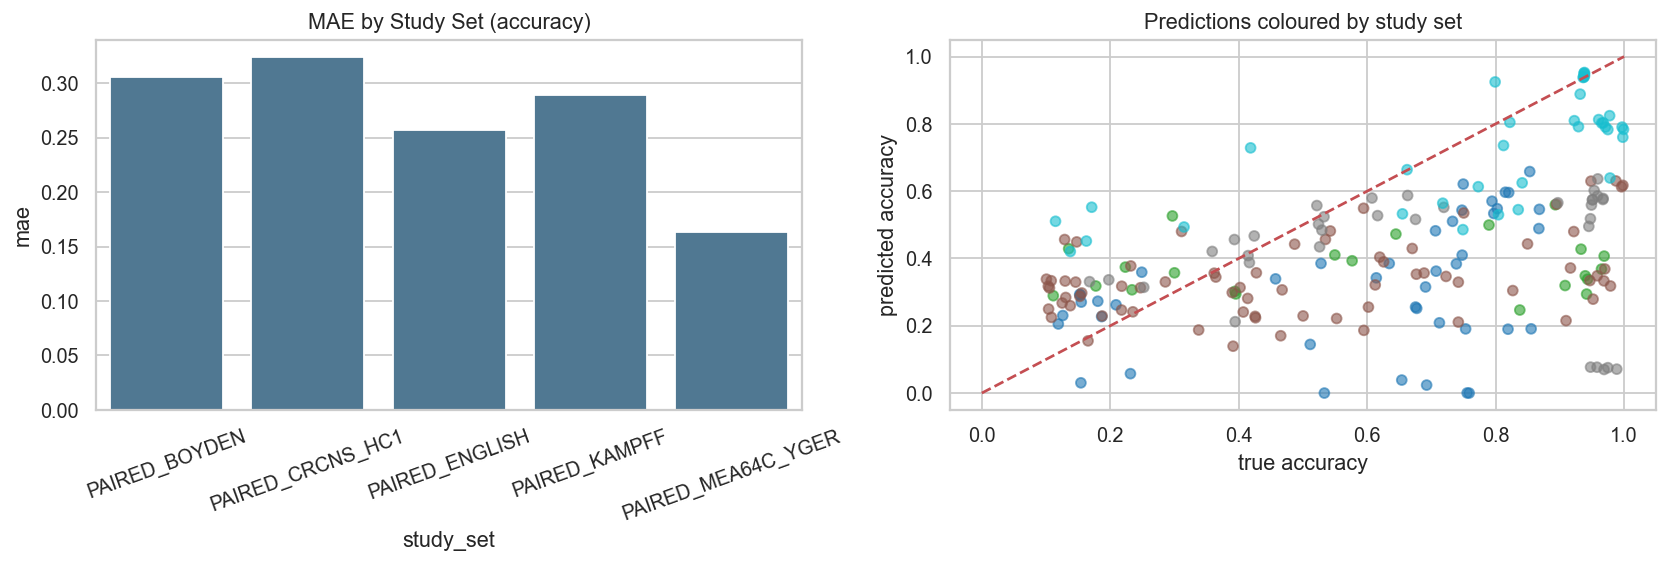

In [26]:
# For the unit_only LightGBM result on accuracy, break down by study set
unit_lgbm = next((r for r in results
                  if r.target == "accuracy"
                  and r.feature_mode == "unit_only"
                  and r.model_name == "lightgbm"), None)

if unit_lgbm is not None:
    p = unit_lgbm.predictions.copy()
    # Merge study_set back in
    p = p.merge(test_df[["row_uid", "study_set"]].astype(str), on="row_uid", how="left")
    breakdown = p.groupby("study_set").apply(lambda g: pd.Series({
        "n": len(g),
        "mae": float(np.mean(g["abs_error"])),
        "rmse": float(np.sqrt(np.mean(g["sq_error"]))),
        "mean_true": float(g["true"].mean()),
        "mean_pred": float(g["pred"].mean()),
    })).reset_index()
    display(breakdown.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.barplot(data=breakdown, x="study_set", y="mae", ax=axes[0], color="#457b9d")
    axes[0].set_title("MAE by Study Set (accuracy)"); axes[0].tick_params(axis="x", rotation=20)
    axes[1].scatter(p["true"], p["pred"], c=p["study_set"].astype("category").cat.codes,
                    cmap="tab10", s=30, alpha=0.6)
    axes[1].plot([0, 1], [0, 1], "r--", lw=1.5)
    axes[1].set_xlabel("true accuracy"); axes[1].set_ylabel("predicted accuracy")
    axes[1].set_title("Predictions coloured by study set")
    plt.tight_layout(); plt.show()

## 6. SHAP Feature Importance (hybrid-trained model)


Top SHAP features — accuracy


,feature,mean_abs_shap,family,rank
0,num__presence_ratio,0.102585,other,1
1,num__isi_cv,0.041808,other,2
2,num__isi_violation_rate,0.032530,other,3
3,num__si_firing_rate_hz,0.031921,spikeinterface,4
4,num__isi_skew,0.027220,other,5
5,num__si_amplitude_cv_median,0.024993,spikeinterface,6
6,num__amp_p5,0.022763,other,7
7,num__si_snr,0.022431,spikeinterface,8
8,num__isi_std_ms,0.019740,other,9
9,num__si_firing_range,0.019642,spikeinterface,10


,family,mean_abs_shap
0,other,0.330704
1,spikeinterface,0.128655
2,waveform,0.078278
3,cosine,0.054644
4,waveform_bins,0.040592
5,acg,0.029784


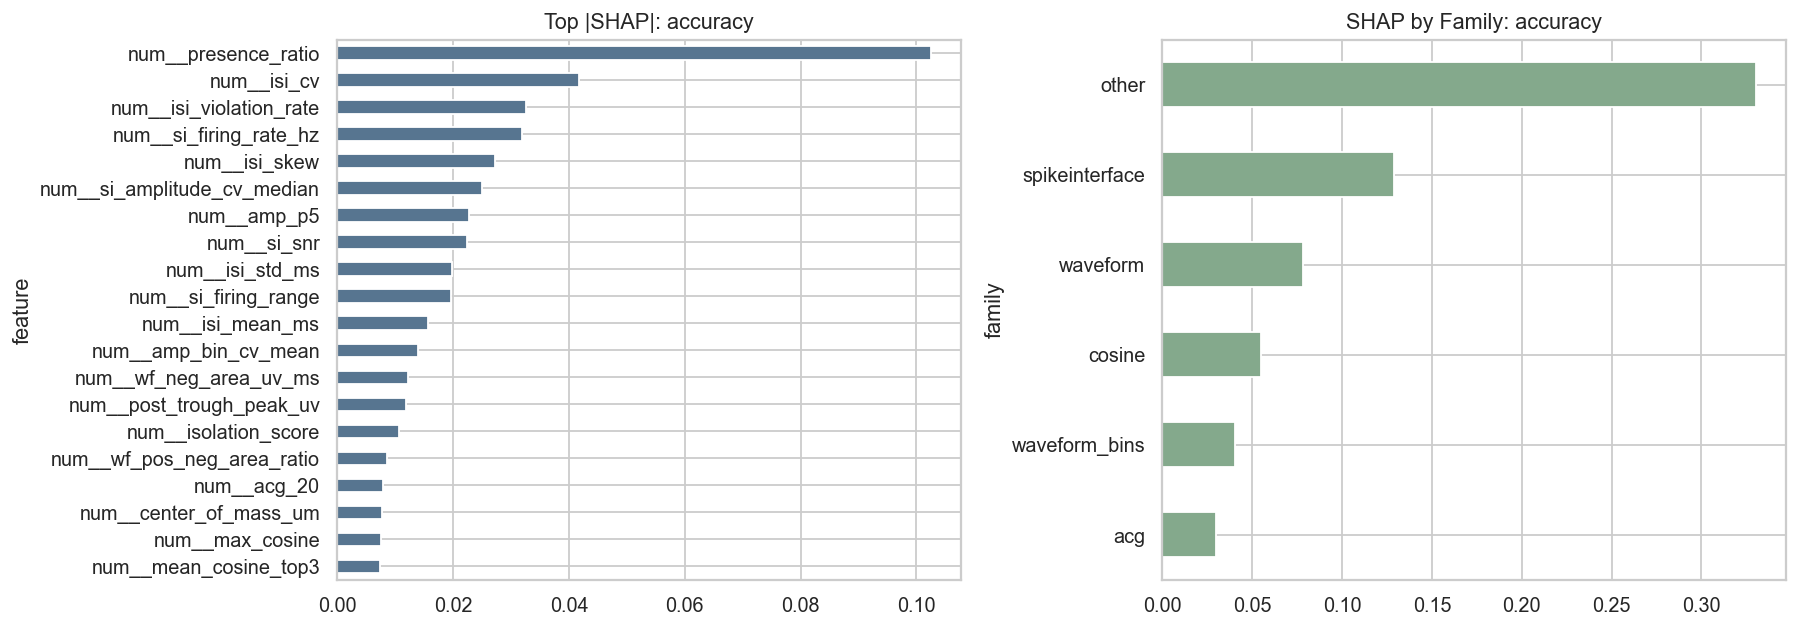


Top SHAP features — fpos


,feature,mean_abs_shap,family,rank
0,num__si_firing_rate_hz,0.065272,spikeinterface,1
1,num__amp_bin_cv_mean,0.059889,other,2
2,num__isi_violation_rate,0.041271,other,3
3,num__isi_mean_ms,0.038620,other,4
4,num__si_amplitude_cv_median,0.036572,spikeinterface,5
5,num__wf_neg_area_uv_ms,0.023201,waveform,6
6,num__si_firing_range,0.019792,spikeinterface,7
7,num__burst_index,0.018054,other,8
8,num__post_trough_peak_uv,0.016868,waveform,9
9,num__wf_peak_trough_ms,0.011836,waveform,10


,family,mean_abs_shap
0,other,0.251559
1,spikeinterface,0.164414
2,waveform,0.103292
3,waveform_bins,0.055127
4,cosine,0.045362
5,acg,0.036234


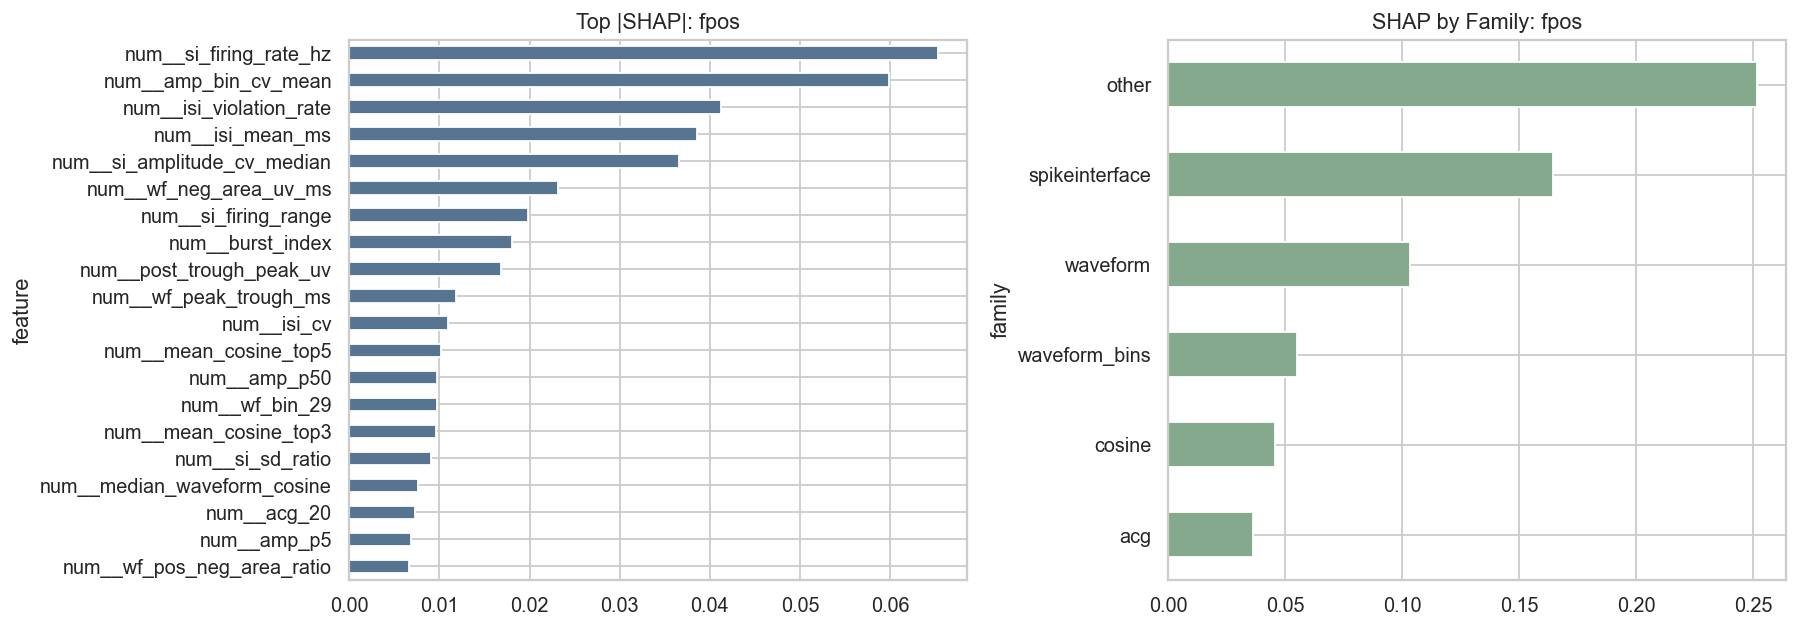


Top SHAP features — fmiss_extended


,feature,mean_abs_shap,family,rank
0,num__presence_ratio,0.132963,other,1
1,num__isi_skew,0.046228,other,2
2,num__isi_std_ms,0.042659,other,3
3,num__si_firing_rate_hz,0.032960,spikeinterface,4
4,num__si_snr,0.022039,spikeinterface,5
5,num__post_trough_peak_uv,0.018619,waveform,6
6,num__isi_mean_ms,0.017027,other,7
7,num__amp_p5,0.016722,other,8
8,num__isi_cv,0.013394,other,9
9,num__isolation_score,0.012482,cosine,10


,family,mean_abs_shap
0,other,0.355402
1,spikeinterface,0.105977
2,waveform,0.073731
3,cosine,0.069474
4,waveform_bins,0.048771
5,acg,0.020119


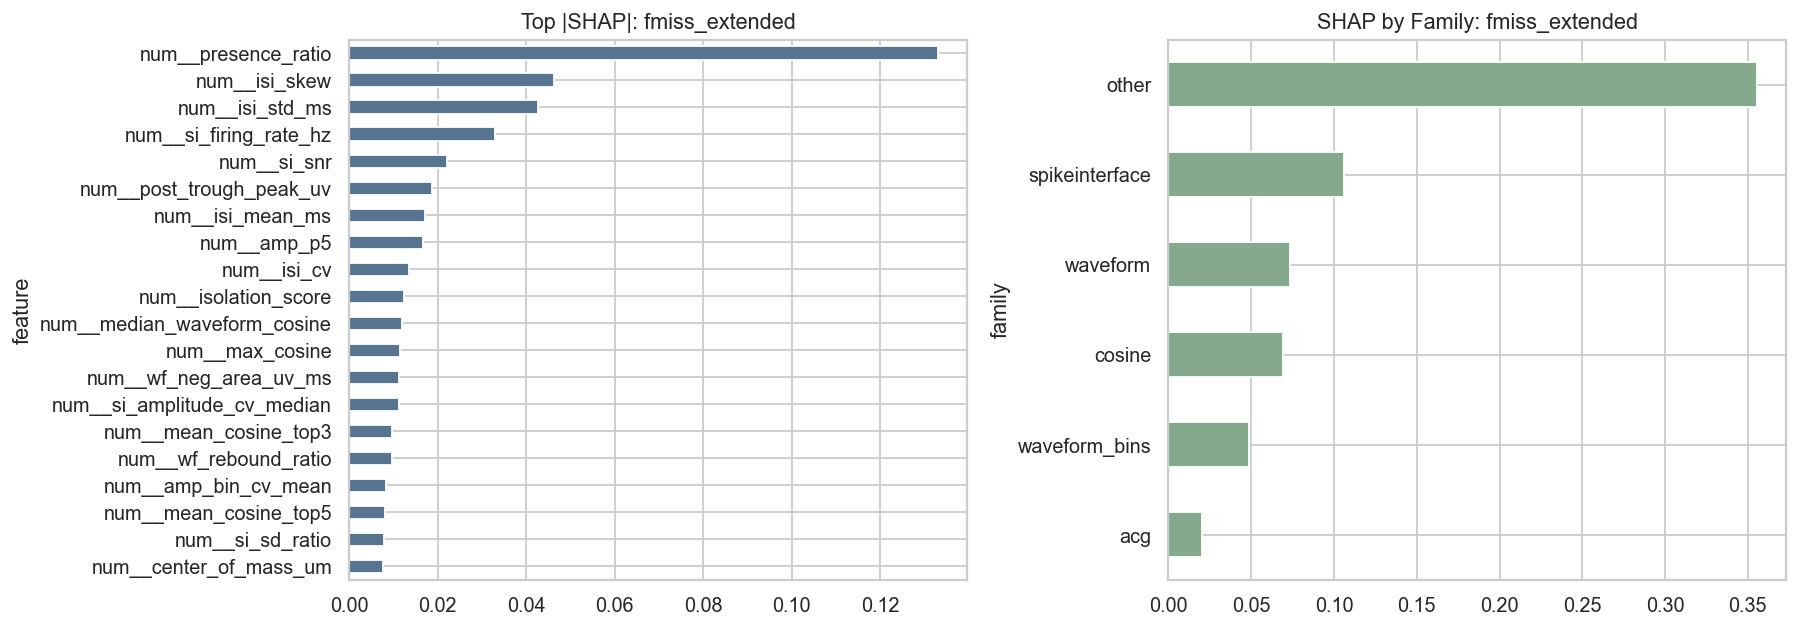

In [27]:
unit_only_spec = next(s for s in specs if s.mode == "unit_only")
analyzer = SHAPAnalyzer()
shap_results = {}

for result in results:
    if result.model_name != "lightgbm" or result.feature_mode != "unit_only":
        continue
    X_test = FeatureSetBuilder.align_frame(test_df, unit_only_spec)
    shap_df = analyzer.analyze(result.fitted_pipe, X_test, result.target)
    shap_results[result.target] = shap_df

for target, shap_df in shap_results.items():
    print(f"\nTop SHAP features — {target}")
    display(shap_df.head(20))
    family_df = SHAPAnalyzer.family_summary(shap_df)
    display(family_df)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    shap_df.head(20).set_index("feature")["mean_abs_shap"].sort_values().plot(kind="barh", ax=axes[0], color="#577590")
    axes[0].set_title(f"Top |SHAP|: {target}")
    family_df.set_index("family")["mean_abs_shap"].sort_values().plot(kind="barh", ax=axes[1], color="#84a98c")
    axes[1].set_title(f"SHAP by Family: {target}")
    plt.tight_layout(); plt.show()

## 7. Save Artifacts

In [ ]:
import json as _json

results_df.to_csv(OUTPUT_DIR / "hybrid_to_paired_results.csv", index=False)

if shap_results:
    payload = {t: df.head(25).set_index("feature")["mean_abs_shap"].to_dict()
               for t, df in shap_results.items() if not df.empty}
    (OUTPUT_DIR / "shap_top_features.json").write_text(_json.dumps(payload, indent=2))

print("Saved to:", OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.iterdir()):
    print(" -", f.name)